# Ejercicion de programación - Regresión Logistica



In [1]:
# 1. IMPORTACIÓN DE LIBRERÍAS

# Librería principal de Deep Learning
import torch
# PyTorch permite crear redes neuronales y entrenarlas

# Para crear datasets personalizados y cargar datos en batches
from torch.utils.data import Dataset, DataLoader
# Dataset permite definir cómo se leen los datos
# DataLoader divide los datos en batches para el entrenamiento

# Librerías para manejo de datos
import numpy as np
# NumPy se usa para cálculos numéricos y manejo de arrays

import pandas as pd
# Pandas permite leer y manipular datasets en formato tabla (CSV)

# Librerías para gráficos
from matplotlib import pyplot as plt
# Matplotlib se usa para visualizar datos y resultados del modelo

# Barra de progreso para entrenamiento
from tqdm import tqdm
# tqdm muestra una barra de progreso durante loops largos (ej. entrenamiento)

In [7]:
# Importa la herramienta de Google Colab para poder conectar Google Drive
from google.colab import drive

# Conecta (monta) Google Drive en la carpeta /content/drive para acceder a archivos del Drive
drive.mount('/content/drive')

# Imprime un mensaje para confirmar que la conexión se realizó
print("Drive conectado correctamente.")

Mounted at /content/drive
Drive conectado correctamente.


In [9]:
# 2. DETECTAR GPU
# (concepto del Cuadernillo 02)

device = "cuda" if torch.cuda.is_available() else "cpu"
# Verifica si hay GPU disponible (cuda)
# Si hay, usa GPU → más rápido
# Si no, usa CPU

print("Dispositivo usado:", device)
# Muestra qué dispositivo se usará para el entrenamiento

Dispositivo usado: cpu


In [11]:
# 4. CARGAR DATASET


data = pd.read_csv('/content/drive/MyDrive/colab/lab5/Copia de Particle Physics Event Classification.csv')
# Lee el archivo CSV desde Google Drive y lo carga en un DataFrame de pandas

print("Primeras filas del dataset:")
# Mensaje para indicar que se mostrará una vista inicial del dataset

display(data.head())
# Muestra las primeras 5 filas del dataset para entender su estructura

print("Dataset cargado correctamente.")
print("Dimensiones del dataset:", data.shape)  # (filas, columnas)

Primeras filas del dataset:


,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,...,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Weight,Label
0,100000,138.470,51.655,97.827,27.980,0.91,124.711,2.666,3.064,41.928,...,2,67.435,2.150,0.444,46.062,1.24,-2.475,113.497,0.002653,s
1,100001,160.937,68.768,103.235,48.146,-999.00,-999.000,-999.000,3.473,2.078,...,1,46.226,0.725,1.158,-999.000,-999.00,-999.000,46.226,2.233584,b
2,100002,-999.000,162.172,125.953,35.635,-999.00,-999.000,-999.000,3.148,9.336,...,1,44.251,2.053,-2.028,-999.000,-999.00,-999.000,44.251,2.347389,b
3,100003,143.905,81.417,80.943,0.414,9.00,-999.000,-999.000,3.310,0.414,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,5.446378,b
4,100004,175.864,16.915,134.805,16.405,-999.00,-999.000,-999.000,3.891,16.405,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,6.245333,b


Dataset cargado correctamente.
Dimensiones del dataset: (250000, 33)


In [12]:
# 6. SEPARAR VARIABLES

# Todas las columnas excepto la etiqueta
X = data.drop(columns=['Label']).values
# Quitamos la columna "Label" del dataset y guardamos el resto como variables de entrada (features)

# Convertimos etiqueta:
# s = señal = 1
# b = fondo = 0
# Estas líneas explican cómo se traducen las etiquetas del dataset a valores numéricos

y = data['Label'].apply(lambda x: 1 if x == 's' else 0).values
# Convertimos la columna Label a números:
# si el valor es 's' (señal) → 1
# si es 'b' (fondo) → 0

print("Forma de X:", X.shape)
# Muestra cuántos ejemplos y variables tiene X

print("Forma de y:", y.shape)
# Muestra cuántas etiquetas hay

Forma de X: (250000, 32)
Forma de y: (250000,)


In [14]:
# 7. NORMALIZACIÓN DE CARACTERÍSTICAS

def normalizar(X):
# Definimos una función para normalizar las variables del dataset

    mu = np.mean(X, axis=0)
    # Calcula la media de cada columna (cada característica)

    sigma = np.std(X, axis=0)
    # Calcula la desviación estándar de cada columna

    X_norm = (X - mu) / sigma
    # Aplica la normalización:
    # resta la media y divide por la desviación estándar
    # esto hace que los datos tengan media≈0 y desviación≈1

    return X_norm, mu, sigma
    # Devuelve los datos normalizados, la media y la desviación


X_norm, mu, sigma = normalizar(X)
# Aplicamos la función de normalización al dataset X


print("Media primeras variables:", mu[:5])
# Muestra las primeras 5 medias calculadas

print("Desviación primeras variables:", sigma[:5])
# Muestra las primeras 5 desviaciones estándar

print("Normalización aplicada correctamente.")
print("Nueva forma de X_norm:", X_norm.shape)

Media primeras variables: [ 2.24999500e+05 -4.90230794e+01  4.92398193e+01  8.11819816e+01
  5.78959617e+01]
Desviación primeras variables: [7.21687836e+04 4.06344834e+02 3.53448149e+01 4.08286089e+01
 6.36555543e+01]
Normalización aplicada correctamente.
Nueva forma de X_norm: (250000, 32)


In [15]:
# 8. DIVISIÓN TRAIN / TEST

split = int(len(X_norm) * 0.8)
# Calcula el índice de corte: 80% para entrenamiento y 20% para prueba

X_train = X_norm[:split]
# Toma el 80% inicial de X como datos de entrenamiento

y_train = y[:split]
# Toma las etiquetas correspondientes para entrenamiento

X_test = X_norm[split:]
# Toma el 20% restante de X como datos de prueba

y_test = y[split:]
# Toma las etiquetas correspondientes para prueba

print("Datos entrenamiento:", X_train.shape)
print("Datos prueba:", X_test.shape)

Datos entrenamiento: (200000, 32)
Datos prueba: (50000, 32)


In [16]:
# 9. DATASET PERSONALIZADO
# (concepto del Cuadernillo 03)

class ParticleDataset(Dataset):
# Creamos una clase que hereda de Dataset para manejar nuestro dataset en PyTorch

    def __init__(self, X, y):
    # Constructor que recibe las variables X y las etiquetas y

        self.X = torch.from_numpy(X).float()
        # Convierte X de NumPy a tensor de PyTorch tipo float

        self.y = torch.from_numpy(y).float().view(-1,1)
        # Convierte y a tensor float y lo reestructura como columna (m x 1)

    def __len__(self):
    # Método que devuelve la cantidad total de ejemplos del dataset

        return len(self.X)

    def __getitem__(self, idx):
    # Método que permite obtener un ejemplo específico del dataset

        return self.X[idx], self.y[idx]
        # Devuelve las características X y la etiqueta y del índice solicitado

print("Clase Dataset personalizada creada.")

Clase Dataset personalizada creada.


In [17]:
# Crear datasets
train_dataset = ParticleDataset(X_train, y_train)
# Creamos el dataset de entrenamiento usando la clase personalizada

test_dataset = ParticleDataset(X_test, y_test)
# Creamos el dataset de prueba usando la misma clase

print("Tamaño train dataset:", len(train_dataset))
print("Tamaño test dataset:", len(test_dataset))

Tamaño train dataset: 200000
Tamaño test dataset: 50000


In [18]:
# 10. DATALOADER (BATCHES)


batch_size = 512
# Tamaño de cada batch: el modelo procesará 512 ejemplos a la vez

train_loader = DataLoader(
    train_dataset,       # Dataset de entrenamiento
    batch_size=batch_size,  # Cantidad de ejemplos por batch
    shuffle=True         # Mezcla los datos en cada epoch para mejorar el entrenamiento
)

test_loader = DataLoader(
    test_dataset,        # Dataset de prueba
    batch_size=batch_size,  # También se procesan en batches
    shuffle=False        # No se mezclan porque solo se evalúa el modelo
)

print("DataLoader creado correctamente.")
print("Batch size:", batch_size)

DataLoader creado correctamente.
Batch size: 512


In [19]:
# Probar un batch
x_batch, y_batch = next(iter(train_loader))
# Obtiene el primer batch del DataLoader de entrenamiento
# iter(train_loader) crea un iterador y next() toma el primer batch

print("Batch X:", x_batch.shape)
# Muestra la forma del batch de datos de entrada

print("Batch y:", y_batch.shape)
# Muestra la forma del batch de etiquetas

Batch X: torch.Size([512, 32])
Batch y: torch.Size([512, 1])


In [20]:
# 11. DEFINICIÓN DEL MODELO

class ClasificadorEventos(torch.nn.Module):
# Definimos una clase de red neuronal para clasificar eventos (señal o fondo)

    def __init__(self, input_size):
    # Constructor del modelo que recibe el número de variables de entrada

        super().__init__()
        # Llama al constructor de la clase base nn.Module

        self.fc1 = torch.nn.Linear(input_size, 64)
        # Primera capa totalmente conectada: input_size → 64 neuronas

        self.relu = torch.nn.ReLU()
        # Función de activación ReLU para introducir no linealidad

        self.fc2 = torch.nn.Linear(64, 32)
        # Segunda capa: 64 → 32 neuronas

        self.fc3 = torch.nn.Linear(32, 1)
        # Capa de salida: 32 → 1 neurona (clasificación binaria)

        self.sigmoid = torch.nn.Sigmoid()
        # Sigmoid convierte la salida en probabilidad entre 0 y 1


    def forward(self, x):
    # Define cómo los datos pasan por la red neuronal

        x = self.fc1(x)
        # Pasa los datos por la primera capa

        x = self.relu(x)
        # Aplica la activación ReLU

        x = self.fc2(x)
        # Segunda capa

        x = self.relu(x)
        # Activación ReLU nuevamente

        x = self.fc3(x)
        # Capa final de la red

        x = self.sigmoid(x)
        # Convierte la salida en probabilidad (0 a 1)

        return x
        # Devuelve la predicción del modelo

print("Arquitectura del modelo definida correctamente.")

Arquitectura del modelo definida correctamente.


In [21]:
# Crear modelo

input_size = X_train.shape[1]
# Obtiene cuántas variables tiene cada ejemplo del dataset
# (número de columnas de X_train → será el tamaño de entrada del modelo)

model = ClasificadorEventos(input_size).to(device)
# Crea el modelo de red neuronal usando ese número de variables
# .to(device) envía el modelo a CPU o GPU según lo detectado antes

print(model)
# Muestra en pantalla la arquitectura completa de la red neuronal

print("Modelo creado correctamente y listo para entrenar.")

ClasificadorEventos(
  (fc1): Linear(in_features=32, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)
Modelo creado correctamente y listo para entrenar.


In [22]:
# 12. FUNCIÓN DE COSTO

# Para clasificación binaria usamos Binary Cross Entropy

criterion = torch.nn.BCELoss()
# Define la función de pérdida Binary Cross Entropy (BCE)
# Esta función mide qué tan lejos está la predicción del modelo
# respecto a la etiqueta real (0 = fondo, 1 = señal)

print("Función de costo configurada: Binary Cross Entropy (BCELoss)")

Función de costo configurada: Binary Cross Entropy (BCELoss)


In [23]:
# 13. OPTIMIZADOR


optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)
# Crea el optimizador Adam
# model.parameters() → indica que optimizará todos los pesos del modelo
# lr=0.001 → tasa de aprendizaje (qué tan rápido se actualizan los pesos)

print("Optimizador configurado: Adam con learning rate = 0.001")

Optimizador configurado: Adam con learning rate = 0.001


In [24]:
# 14. FUNCIÓN PARA CALCULAR PRECISIÓN

def calcular_precision(y_pred, y_true):
# Función que calcula qué tan preciso es el modelo comparando
# las predicciones con las etiquetas reales

    y_pred = (y_pred > 0.5).float()
    # Convierte las probabilidades en clases:
    # si probabilidad > 0.5 → clase 1 (señal)
    # si probabilidad ≤ 0.5 → clase 0 (fondo)

    correctos = (y_pred == y_true).sum()
    # Cuenta cuántas predicciones coinciden con las etiquetas reales

    precision = correctos / len(y_true)
    # Calcula la precisión como:
    # predicciones correctas / total de ejemplos

    return precision.item()
    # Devuelve el valor como número normal de Python

print("Función para calcular precisión definida correctamente.")

Función para calcular precisión definida correctamente.


In [25]:
# 15. FUNCIÓN DE ENTRENAMIENTO


def entrenar(model, train_loader, test_loader, epochs=25, PATH="./checkpoint_clasificacion.pt"):
# Función que entrena el modelo durante varias épocas
# También guarda el mejor modelo usando checkpoints

    model.to(device)
    # Envía el modelo a CPU o GPU según el dispositivo detectado

    best_acc = 0
    # Variable para guardar la mejor precisión obtenida en test

    train_losses = []
    test_losses = []
    # Listas para guardar la evolución del costo (train y test)

    train_accs = []
    test_accs = []
    # Listas para guardar la evolución de la precisión

    for epoch in range(1, epochs+1):
    # Bucle principal de entrenamiento (una epoch = una pasada por todo el dataset)

        model.train()
        # Pone el modelo en modo entrenamiento

        losses = []
        accs = []
        # Listas temporales para guardar métricas del epoch actual

        barra = tqdm(train_loader)
        # Barra de progreso para visualizar el entrenamiento

        for X_batch, y_batch in barra:
        # Recorre los datos por batches

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            # Envía los datos al dispositivo (CPU o GPU)

            # Forward
            y_pred = model(X_batch)
            # El modelo genera predicciones para el batch

            # Calcular costo
            loss = criterion(y_pred, y_batch)
            # Calcula el error entre predicción y etiqueta real

            # Reiniciar gradientes
            optimizer.zero_grad()
            # Limpia gradientes acumulados del paso anterior

            # Backpropagation
            loss.backward()
            # Calcula gradientes usando retropropagación

            # Actualizar pesos
            optimizer.step()
            # Ajusta los pesos del modelo usando el optimizador

            losses.append(loss.item())
            # Guarda el valor del costo

            acc = calcular_precision(y_pred, y_batch)
            # Calcula la precisión del batch actual

            accs.append(acc)
            # Guarda la precisión

            barra.set_description(f"loss {np.mean(losses):.4f} acc {np.mean(accs):.4f}")
            # Actualiza la barra de progreso mostrando métricas

        # Promedio entrenamiento
        train_loss = np.mean(losses)
        train_acc = np.mean(accs)
        # Calcula el promedio de costo y precisión del entrenamiento

        # Evaluar en test
        test_loss, test_acc = evaluar(model, test_loader)
        # Evalúa el modelo en el dataset de prueba

        train_losses.append(train_loss)
        test_losses.append(test_loss)
        # Guarda evolución del costo

        train_accs.append(train_acc)
        test_accs.append(test_acc)
        # Guarda evolución de precisión

        print(f"Epoch {epoch}/{epochs} | Train Loss {train_loss:.4f} | Test Loss {test_loss:.4f} | Train Acc {train_acc:.4f} | Test Acc {test_acc:.4f}")
        # Muestra resumen del epoch

        # Guardar mejor modelo
        if test_acc > best_acc:
        # Si la precisión en test mejora, se guarda el modelo

            best_acc = test_acc
            # Actualiza la mejor precisión

            torch.save(model.state_dict(), PATH)
            # Guarda los pesos del modelo

            print("Mejor modelo guardado")

    # cargar mejor modelo
    model.load_state_dict(torch.load(PATH))
    # Al final del entrenamiento se cargan los mejores pesos

    print("Entrenamiento finalizado. Mejor modelo cargado.")

    return train_losses, test_losses, train_accs, test_accs
    # Devuelve todas las métricas para graficarlas luego

In [29]:
# 16. FUNCIÓN DE EVALUACIÓN

def evaluar(model, dataloader):
# Función que evalúa el modelo en un dataset (test o validación)

    model.eval()
    # Cambia el modelo a modo evaluación (desactiva dropout, batchnorm, etc.)

    losses = []
    accs = []
    # Listas para guardar el costo y la precisión de cada batch

    with torch.no_grad():
    # Desactiva el cálculo de gradientes para ahorrar memoria y acelerar evaluación

        for X_batch, y_batch in dataloader:
        # Recorre todo el dataset por batches

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            # Envía los datos al dispositivo (CPU o GPU)

            y_pred = model(X_batch)
            # El modelo genera predicciones

            loss = criterion(y_pred, y_batch)
            # Calcula el costo del batch

            acc = calcular_precision(y_pred, y_batch)
            # Calcula la precisión del batch

            losses.append(loss.item())
            # Guarda el costo

            accs.append(acc)
            # Guarda la precisión


    print("Evaluación completada.")
    print("Costo promedio:", np.mean(losses))
    print("Precisión promedio:", np.mean(accs) * 100, "%")

    return np.mean(losses), np.mean(accs)
    # Devuelve el costo promedio y la precisión promedio

In [30]:
# 17. ENTRENAR EL MODELO

train_loss, test_loss, train_acc, test_acc = entrenar(
    model,
    train_loader,
    test_loader
)
# Llama a la función entrenar() que definimos antes
# model → la red neuronal que queremos entrenar
# train_loader → datos de entrenamiento en batches
# test_loader → datos de prueba para evaluar el modelo

# La función devuelve:
# train_loss → lista con el costo en entrenamiento por cada epoch
# test_loss → lista con el costo en test por cada epoch
# train_acc → lista con la precisión de entrenamiento por epoch
# test_acc → lista con la precisión en test por epoch

print("Entrenamiento terminado correctamente.")
print("Última precisión de entrenamiento:", train_acc[-1] * 100, "%")
print("Última precisión de prueba:", test_acc[-1] * 100, "%")

loss 0.2292 acc 0.9009: 100%|██████████| 391/391 [00:08<00:00, 47.40it/s]


Evaluación completada.
Costo promedio: 0.11120208527664749
Precisión promedio: 95.83190977573395 %
Epoch 1/25 | Train Loss 0.2292 | Test Loss 0.1112 | Train Acc 0.9009 | Test Acc 0.9583
Mejor modelo guardado


loss 0.0956 acc 0.9646: 100%|██████████| 391/391 [00:04<00:00, 78.72it/s]


Evaluación completada.
Costo promedio: 0.08412594393808015
Precisión promedio: 96.94912007876805 %
Epoch 2/25 | Train Loss 0.0956 | Test Loss 0.0841 | Train Acc 0.9646 | Test Acc 0.9695
Mejor modelo guardado


loss 0.0788 acc 0.9711: 100%|██████████| 391/391 [00:05<00:00, 65.52it/s]


...

Evaluación completada.
Costo promedio: 0.008520933690157776
Precisión promedio: 99.81958744477252 %
Epoch 23/25 | Train Loss 0.0057 | Test Loss 0.0085 | Train Acc 0.9988 | Test Acc 0.9982


loss 0.0049 acc 0.9990: 100%|██████████| 391/391 [00:05<00:00, 68.39it/s] 


Evaluación completada.
Costo promedio: 0.007486291788043264
Precisión promedio: 99.84748923048681 %
Epoch 24/25 | Train Loss 0.0049 | Test Loss 0.0075 | Train Acc 0.9990 | Test Acc 0.9985


loss 0.0063 acc 0.9984: 100%|██████████| 391/391 [00:04<00:00, 80.79it/s]


Evaluación completada.
Costo promedio: 0.007967555149439342
Precisión promedio: 99.8664700255102 %
Epoch 25/25 | Train Loss 0.0063 | Test Loss 0.0080 | Train Acc 0.9984 | Test Acc 0.9987
Entrenamiento finalizado. Mejor modelo cargado.
Entrenamiento terminado correctamente.
Última precisión de entrenamiento: 99.83965393222506 %
Última precisión de prueba: 99.8664700255102 %


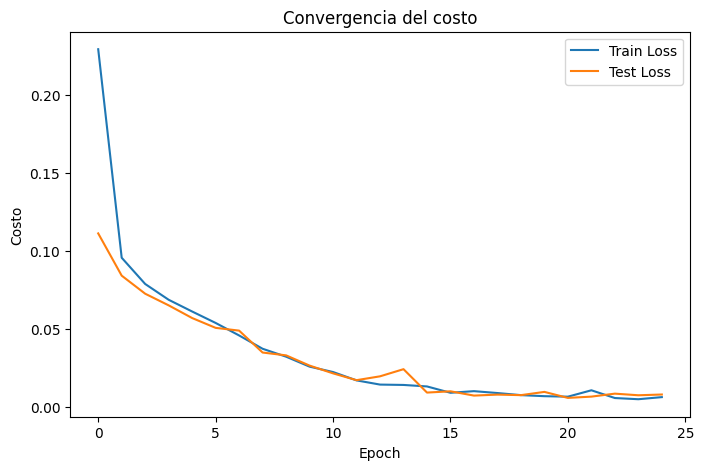

In [31]:
# 18. GRÁFICA DE COSTO

plt.figure(figsize=(8,5))

plt.plot(train_loss, label="Train Loss")
plt.plot(test_loss, label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Costo")

plt.title("Convergencia del costo")

plt.legend()

plt.show()

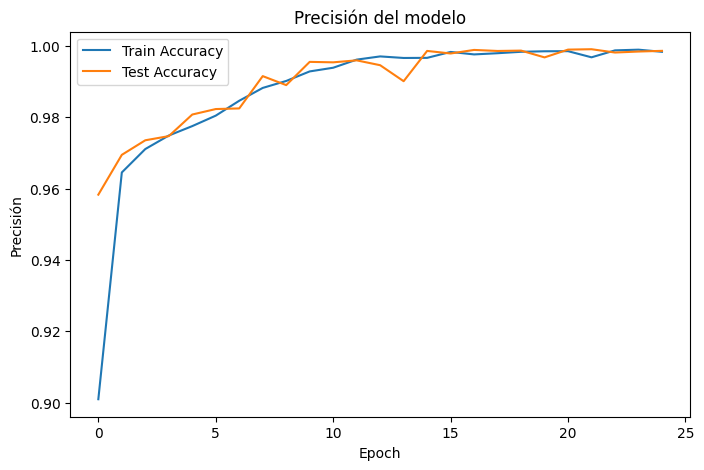

In [32]:
# 19. GRÁFICA DE PRECISIÓN

plt.figure(figsize=(8,5))

plt.plot(train_acc, label="Train Accuracy")
plt.plot(test_acc, label="Test Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Precisión")

plt.title("Precisión del modelo")

plt.legend()

plt.show()

In [35]:
# 21. PRECISIÓN FINAL DEL MODELO


model.eval()
# Coloca el modelo en modo evaluación

X_tensor = torch.from_numpy(X_norm).float().to(device)
# Convierte los datos a tensor de PyTorch y los envía a CPU/GPU

with torch.no_grad():
    probabilidades = model(X_tensor)
# El modelo genera probabilidades de clase 1 (señal)

probabilidades = probabilidades.cpu().numpy()
# Convertimos las probabilidades a numpy

predicciones = (probabilidades > 0.5).astype(int)
# Convertimos probabilidades en clases
# >0.5 = señal (1)
# <=0.5 = fondo (0)

predicciones = predicciones.flatten()
# Convertimos a vector 1D

# calcular precisión
correctos = np.sum(predicciones == y)
# Cuenta predicciones correctas

total = len(y)
# Número total de eventos

precision = (correctos / total) * 100
# Calcula el porcentaje de precisión

print("RESULTADO FINAL DEL MODELO")

print("Eventos correctamente clasificados:", correctos)
print("Total de eventos:", total)

print("Precisión del modelo: {:.2f} %".format(precision))

RESULTADO FINAL DEL MODELO
Eventos correctamente clasificados: 249825
Total de eventos: 250000
Precisión del modelo: 99.93 %


In [37]:
# 22. MATRIZ DE CONFUSIÓN


from sklearn.metrics import confusion_matrix
# Importa la función para calcular la matriz de confusión

model.eval()
# Modo evaluación

X_tensor = torch.from_numpy(X_test).float().to(device)
# Convertir datos de prueba a tensor

with torch.no_grad():
    probabilidades = model(X_tensor)
# Obtener probabilidades del modelo

probabilidades = probabilidades.cpu().numpy()
# Convertir a numpy

predicciones_test = (probabilidades > 0.5).astype(int).flatten()
# Convertir probabilidades a clases (0 o 1)

y_test_np = y_test
# Etiquetas reales

cm = confusion_matrix(y_test_np, predicciones_test)
# Calcular matriz de confusión

print("Matriz de confusión:")
print(cm)

print("Interpretación:")
print("[ TN  FP ]")
print("[ FN  TP ]")
print("Filas = valores reales | Columnas = predicciones")

Matriz de confusión:
[[32818    19]
 [   25 17138]]
Interpretación:
[ TN  FP ]
[ FN  TP ]
Filas = valores reales | Columnas = predicciones


In [38]:
# 23. EJEMPLO DE PREDICCIÓN DE UN EVENTO

evento = X[0]
# Tomamos el primer evento del dataset original

evento_norm = (evento - mu) / sigma
# Normalizamos el evento usando la media (mu) y desviación estándar (sigma)
# que se calcularon durante el preprocesamiento

evento_norm = evento_norm.reshape(1,-1)
# Cambiamos la forma del vector a (1, n_features)
# porque el modelo espera un batch de datos

evento_tensor = torch.from_numpy(evento_norm).float().to(device)
# Convertimos el evento a tensor de PyTorch
# y lo enviamos al dispositivo (CPU o GPU)

model.eval()
# Ponemos el modelo en modo evaluación

with torch.no_grad():
    prob = model(evento_tensor)
# El modelo genera la probabilidad de que el evento sea señal

prob = prob.cpu().numpy()
# Convertimos la probabilidad a numpy

pred = (prob > 0.5).astype(int)
# Convertimos probabilidad a clase
# >0.5 = señal (1)
# <=0.5 = fondo (0)

print("PREDICCIÓN DE UN EVENTO")

print("Probabilidad de que sea SEÑAL:", round(prob[0][0]*100,2), "%")
# Muestra la probabilidad en porcentaje

if pred[0][0] == 1:
    print("Predicción del modelo: SEÑAL")
else:
    print("Predicción del modelo: FONDO")
# Muestra la clase predicha

PREDICCIÓN DE UN EVENTO
Probabilidad de que sea SEÑAL: 99.06 %
Predicción del modelo: SEÑAL


In [41]:
# 23. PREDICCIÓN DE UN EVENTO


evento = X[0]
# Tomamos el primer evento del dataset original

evento_norm = (evento - mu) / sigma
# Normalizamos el evento usando la media y desviación estándar

evento_norm = evento_norm.reshape(1,-1)
# Cambiamos la forma a (1, número_de_variables)
# porque el modelo espera un batch de datos

evento_tensor = torch.from_numpy(evento_norm).float().to(device)
# Convertimos el evento a tensor de PyTorch

model.eval()
# Colocamos el modelo en modo evaluación

with torch.no_grad():
    prob = model(evento_tensor)
# El modelo genera la probabilidad de que el evento sea señal

prob = prob.cpu().numpy()
# Convertimos la salida a numpy

pred = (prob > 0.5).astype(int)
# Convertimos probabilidad a clase
# >0.5 → señal
# <=0.5 → fondo

print("Probabilidad de señal:", prob[0][0])
print("Predicción (0=fondo,1=señal):", int(pred[0][0]))

Probabilidad de señal: 0.99063057
Predicción (0=fondo,1=señal): 1


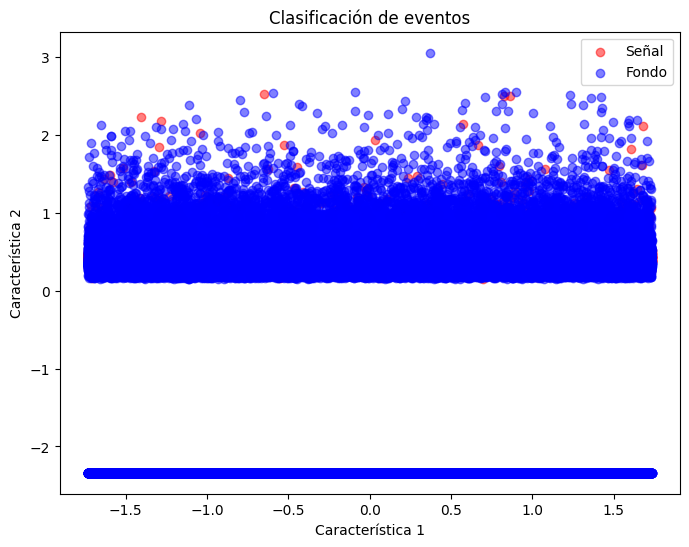

In [42]:
# 24. VISUALIZACIÓN DE CLASES

x1 = X_norm[:,0]
x2 = X_norm[:,1]

plt.figure(figsize=(8,6))

plt.scatter(x1[y==1], x2[y==1], c='red', label='Señal', alpha=0.5)
plt.scatter(x1[y==0], x2[y==0], c='blue', label='Fondo', alpha=0.5)

plt.xlabel("Característica 1")
plt.ylabel("Característica 2")

plt.title("Clasificación de eventos")

plt.legend()

plt.show()